# This notebook perofms a case study comparing GPROF V7, ERA5, and the SatRain retrievals


In [17]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from typing import Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## GPROF


In [18]:
def load_gprof_precip(path: Path, scan_start: int, scan_end: int) -> xr.Dataset:
    """
    Load GPROF precipitation.

    Args:
        path: A Path object pointing to the IMERG file to load.
        scan_start: The start scan of the collocation.
        scan_end: Index pointing to the first scan that is not part of 
             the collocation anymore.

    Return:
        An xarray.Dataset containing the 'surface_precip', 'probability_of_precip',
        'precipitation_flag', 'probability_of_heavy_precip', and 'heavy_precip_flag'
        extracted from the GPROF file pointed to by 'path'.
    """
    slc = slice(scan_start, scan_end)
    with h5py.File(path) as data:
        lats = data["S1/Latitude"][slc]
        lons = data["S1/Longitude"][slc]
        
        surface_precip = data["S1/surfacePrecipitation"][slc]
        invalid = surface_precip < 0
        surface_precip[invalid] = np.nan
        probability_of_precip = data["S1/probabilityOfPrecip"][slc] / 100.0
        probability_of_precip[invalid] = np.nan
        precipitation_flag = data["S1/precipitationYesNoFlag"][slc].astype(np.float32)
        precipitation_flag[invalid] = np.nan
        probability_of_heavy_precip = np.clip(surface_precip / 100, 0.0, 1.0)
        probability_of_heavy_precip[invalid] = np.nan

    data.close()
    del data

    return xr.Dataset({
        "longitude": (("scan", "pixel"), lons),
        "latitude": (("scan", "pixel"), lats),
        "surface_precip": (("scan", "pixel"), surface_precip),
        "probability_of_precip": (("scan", "pixel"), probability_of_precip),
        "precip_flag": (("scan", "pixel"), precipitation_flag),
        "probability_of_heavy_precip": (("scan", "pixel"), probability_of_heavy_precip),
        "heavy_precip_flag": (("scan", "pixel"), surface_precip > 10),
    })


In [19]:
from pyresample.geometry import SwathDefinition
from pansat.utils import resample_data
from pansat.products.satellite.gpm import l2a_gprof_gpm_gmi_v07a, l2a_gprof_gpm_gmi_v07b

def retrieve_gprof(input_data: xr.Dataset) -> xr.Dataset:
    """
    Retrieval callback function to load GPROF data corresponding to IPWGML SPR evaluation data.

    Args:
        input_data: An xarray.Dataset containing the retrieval input data.

    Return:
        An xarray.Dataset containing the retrieval results.
    """
    time = input_data.time.mean().data
    recs = l2a_gprof_gpm_gmi_v07a.get(time)
    if len(recs) == 0:
        recs = l2a_gprof_gpm_gmi_v07b.get(time)
    rec = recs[0]
    input_file = input_data.attrs["gpm_input_file"]
    scan_start = input_data.attrs["scan_start"]
    scan_end = input_data.attrs["scan_end"]
    results_gprof = load_gprof_precip(rec.local_path, scan_start, scan_end)

    n_batches = input_data.batch.size
    batch_results = []
    for batch_ind in range(n_batches):
        lons = input_data.longitude[batch_ind]
        lats = input_data.latitude[batch_ind]
        lons, lats = np.meshgrid(lons, lats)
        grid = SwathDefinition(lons, lats)
        results_gprof_r = resample_data(results_gprof, grid, radius_of_influence=10e3)
        batch_results.append(results_gprof_r.drop_vars(("latitude", "longitude")))
    return xr.concat(batch_results, dim="batch")

## ERA5

In [20]:
from satrain.input import Ancillary
anc = Ancillary(variables=["total_precipitation"])

def retrieve_era5(input_data: xr.Dataset) -> xr.Dataset:
    """
    Retrieval callback function to load GPROF data corresponding to IPWGML SPR evaluation data.

    Args:
        input_data: An xarray.Dataset containing the retrieval input data.

    Return:
        An xarray.Dataset containing the retrieval results.
    """
    lons = input_data.longitude.data
    lats = input_data.latitude.data
    tp = input_data.ancillary.data[:, 0]
        
    return xr.Dataset({
        "surface_precip": (("batch", "latitude", "longitude"), tp * 1e3),
    })

## SatRain retrievals

In [21]:
from pytorch_retrieve import load_model
model_gmi = load_model("/home/simon/src/ipwgml/models/satrain/gmi/ipwgml_gmi.pt")
model_geo = load_model("/home/simon/src/ipwgml/models/satrain/geo/checkpoints/ipwgml_geo-v3.ckpt")
model_geo_ir = load_model("/home/simon/src/ipwgml/models/satrain/geo_ir/ipwgml_geo_ir.pt")

In [22]:
from typing import Any, List, Dict
import torch
from torch import nn
import xarray as xr

from satrain.input import calculate_input_features

class PytorchRetrieval:
    """
    This class provides a generic retrieval callback function for PyTorch-based
    retrievals.

    The PytorchRetrieval wraps around a torch.nn.Module and extracts the input
    data from the xarray.Dataset provided by the ipwgml.evaluation.Evaluator
    and feeds it into the module. It then transform the output back from
    PyTorch tensors to an xarray.Dataset containing the retrieval results.

    The PytorchRetrieval class expects the module to return a dict containing
    the keys 'surface_precip', 'probability_of_precip', and
    'probability_of_heavy_precip'.
    """
    def __init__(
            self,
            model: nn.Module,
            retrieval_input: List[str | Dict[str, Any]],
            precip_threshold: float = 0.5,
            heavy_precip_threshold: float = 0.5,
            stack: bool = False,
            logits: bool = True,
            device: torch.device = torch.device("cpu"),
            dtype: torch.dtype = torch.float32,
    ):
        """
        Args:
            model: A torch.nn.Module implementing the retrieval.
            retrieval_input: A list defining the retrieval input.
            precip_threshold: The probability threshold to apply to
                transform the 'probability_of_precip' to a 'precip_flag'
                output.
            heavy_precip_threshold: Same as 'precip_threshold' but for
                heavy precip flag output.
            stack: Whether or not the model expects the input data to
                be stacked ('True') or as dictionary.
            logits: Whether the model returns logits instead of probabilities.
            device: A torch.device defining the device on which to perform
                inference.
            dtype: The dtype to which to convert the retrieval input.
        """
        self.model = model.to(device=device).eval()
        self.features = calculate_input_features(retrieval_input, stack=False)
        self.precip_threshold = precip_threshold
        self.heavy_precip_threshold = heavy_precip_threshold
        self.stack = stack
        self.logits = logits
        self.device = device
        self.dtype = dtype

    def __call__(self, input_data: xr.Dataset) -> xr.Dataset:
        """
        Run retrieval on input data.
        """
        feature_dim = 0
        if "scan" in input_data.dims:
            spatial_dims = ("scan", "pixel")
        elif "latitude" in input_data.dims:
            spatial_dims = ("latitude", "longitude")
        else:
            spatial_dims = ()

        if "batch" in input_data.dims:
            dims = ("batch",) + spatial_dims
            feature_dim += 1
        else:
            dims = spatial_dims


        features = self.features
        inpt = {}
        for name in features:
            inpt_data = torch.tensor(input_data[name].data).to(self.device, self.dtype)
            if len(dims) == 1:
                inpt_data = inpt_data.transpose(0, 1)
            inpt[name] = inpt_data

        if self.stack:
            inpt = torch.cat(list(inpt.values()), dim=feature_dim)

        with torch.no_grad():
            pred = self.model(inpt)
            surface_precip = pred["surface_precip"].expected_value().float().cpu().numpy()
            #pop = pred["precip_mask"].probability().float().cpu().numpy()
            #precip_mask = 0.5 < pop 
            #pop_heavy = pred["heavy_precip_mask"].probability().float().cpu().numpy()
            #heavy_precip_mask = 0.5 < pop_heavy
            
            results = xr.Dataset()
            results["surface_precip"] = (dims, surface_precip[:, 0])
            #results["probability_of_precip"] = (dims, pop[:, 0])
            #results["precip_flag"] = (dims, precip_mask[:, 0])
            #results["probability_of_heavy_precip"] = (dims, pop_heavy[:, 0])
            #results["heavy_precip_flag"] = (dims, heavy_precip_mask[:, 0])

        return results


In [23]:
import torch
gmi_retrieval = PytorchRetrieval(
    model_gmi,
    retrieval_input=["gmi"],
    device=torch.device("cpu"),
    dtype=torch.float32 
)
geo_retrieval = PytorchRetrieval(
    model_geo,
    retrieval_input=["geo"],
    device=torch.device("cpu"),
    dtype=torch.float32 
)
geo_ir_retrieval = PytorchRetrieval(
    model_geo_ir,
    retrieval_input=["geo_ir"],
    device=torch.device("cpu"),
    dtype=torch.float32 
)

In [24]:
from satrain.evaluation import Evaluator
from satrain.target import TargetConfig

domain = "conus"
evaluator = Evaluator(
    domain=domain,
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[
        {"name": "gmi", "normalize": "minmax", "nan": -2},
        {"name": "geo", "normalize": "minmax", "nan": -2, "channels": [1, 2, 4, 6, 7, 9, 10, 11, 14, 15]},
        {"name": "geo_ir", "normalize": "minmax", "nan": -2},
        {"name": "ancillary", "variables": ["total_precipitation"]},
    ],
    download=True,
)
print(f"Found {len(evaluator)} overpasses.")

Found 2912 overpasses.


## Scene Stats

In [9]:
from tqdm import tqdm

lon_c = []
lat_c = []
total_raining = []
mean_precip = []
total_snow = []
total_hail = []
total_convective = []
total_stratiform = []

for path in tqdm(evaluator.target_gridded):
    with xr.open_dataset(path) as data:
        lons = data.longitude.data
        lon_c.append(lons.mean())
        lats = data.latitude.data
        lat_c.append(lats.mean())
        scan_index = data.scan_index.data
        surface_precip = data.surface_precip.data
        valid = (0 <= scan_index) * (0 <= surface_precip)
        total_raining.append((1e-3 < surface_precip[valid]).sum())
        mean_precip.append(surface_precip[valid].mean())
        
        if "convective_fraction" in data:
            conv_frac = data.convective_fraction.data
            total_convective.append(conv_frac[valid].sum())
            
            snow_frac = data.snow_fraction.data
            total_snow.append(snow_frac[valid].sum())
            
            hail_frac = data.hail_fraction.data
            total_hail.append(hail_frac[valid].sum())
            
            stratiform_frac = data.stratiform_fraction.data
            total_stratiform.append(stratiform_frac[valid].sum())

stats = {
    "latitude": (("scenes",), np.array(lat_c)),
    "longitude": (("scenes",), np.array(lon_c)),
    "total_raining": (("scenes",), np.array(total_raining)),
    "mean_precip": (("scenes",), np.array(mean_precip)),
    "total_snow": (("scenes",), np.array(total_snow)),
    "total_hail": (("scenes",), np.array(total_hail)),
    "total_convective": (("scenes",), np.array(total_convective)),
    "total_stratiform": (("scenes",), np.array(total_stratiform)),
}
            

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 2912/2912 [04:03<00:00, 11.96it/s]


In [10]:
stats = xr.Dataset(stats)

In [11]:
inds = np.argsort(stats.total_raining.data)[::-1]
scenes_west = inds[stats.longitude.data[inds] < -110]

In [12]:
stats = xr.Dataset(stats)

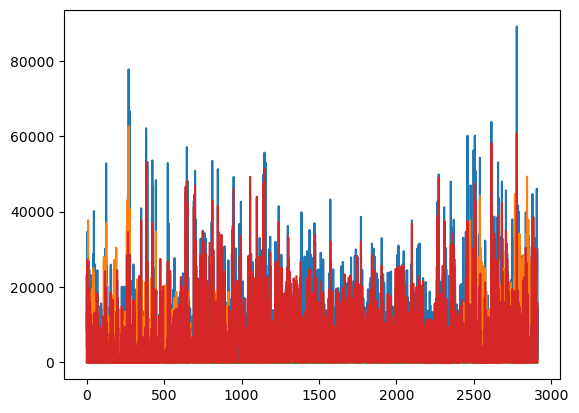

In [13]:
plt.plot(stats.total_raining)
plt.plot(stats.total_snow)
plt.plot(stats.total_convective)
plt.plot(stats.total_stratiform)

In [14]:
stats.total_convective.data[811]

3211.4763779527557

In [15]:
np.argsort(np.nan_to_num(stats.total_convective.data, nan=0.0, copy=True))[::-1]

array([ 811, 1383, 1476, ..., 1101, 1104, 1090])

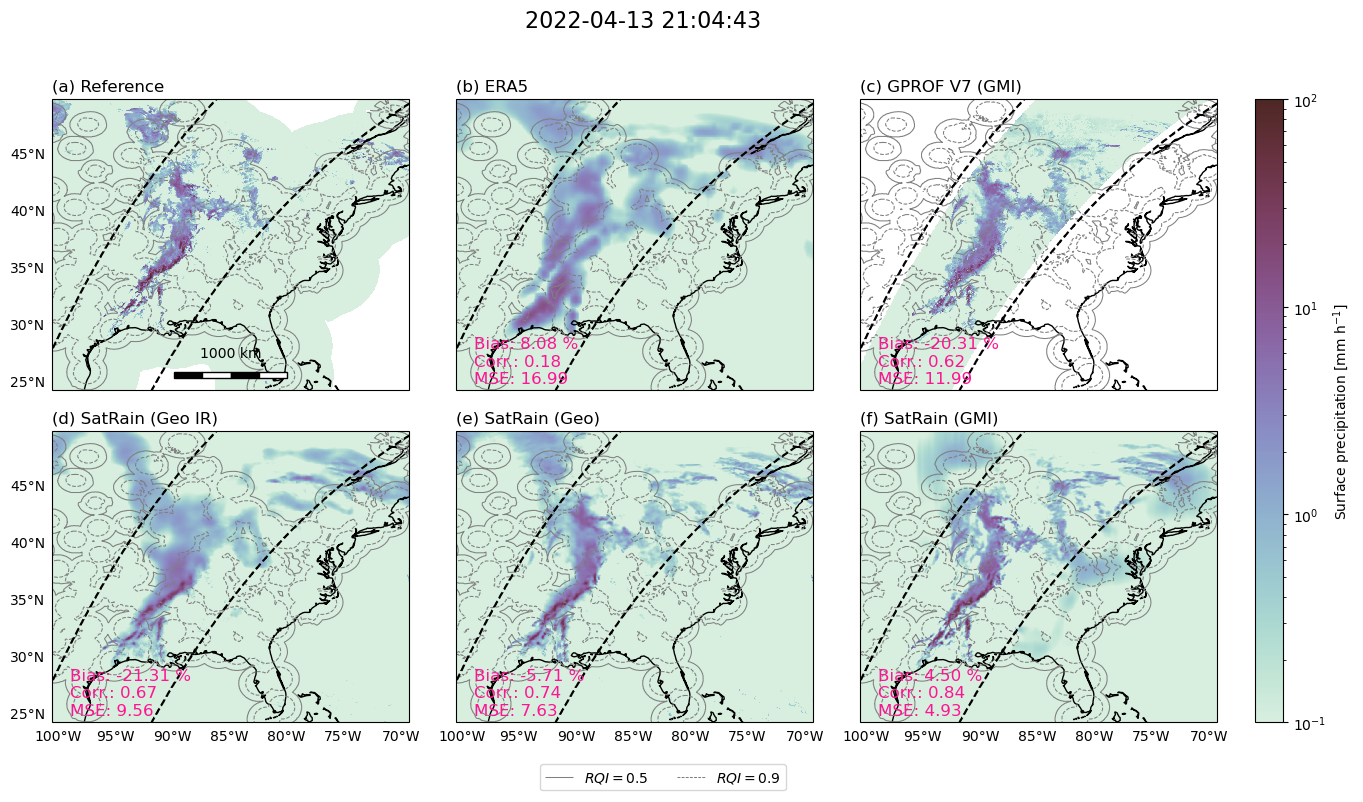

In [30]:
fig = evaluator.plot_retrieval_results(
    811,
    retrieval_fn={
        "ERA5": retrieve_era5,
        "GPROF V7 (GMI)": retrieve_gprof,
        "SatRain (Geo IR)": geo_ir_retrieval,
        "SatRain (Geo)": geo_retrieval,
        "SatRain (GMI)": gmi_retrieval
    },
    include_metrics=True,
    input_data_format="spatial",
    batch_size=32,
    tile_size=(256, 256),
    overlap=64,
    n_rows=2,
    contour_legend=True,
    swath_boundaries=True
)
fig.savefig("../figures_revised/fig09.pdf", bbox_inches="tight", dpi=200)

In [ ]:
fig = evaluator.plot_retrieval_results(
    scenes_west[3],
    retrieval_fn={
        "ERA5": retrieve_era5,
        "GPROF V7 (GMI)": retrieve_gprof,
        "SatRain (GEO IR)": geo_ir_retrieval,
        "SatRain (GEO)": geo_retrieval,
        "SatRain (GMI)": gmi_retrieval
    },
    include_metrics=True,
    input_data_format="spatial",
    batch_size=32,
    tile_size=(256, 256),
    overlap=64,
    n_rows=2,
    contour_legend=False,
    swath_boundaries=True
)
fig.savefig("../case_west.png", bbox_inches="tight", dpi=200)

WARNING  Found table named 'satellite.goes.l1b_goes18_rad_rgb_full_disk' in database but could not load find a     
         corresponding pansat product.

WARNING  Found table named 'dem.copernicus' in database but could not load find a corresponding pansat product.

WARNING  Found table named 'dem.copernicus' in database but could not load find a corresponding pansat product.

Please enter your pansat user password:


 ········


[[52.00282943 52.00282943 52.00282943 ... 52.00282943 52.00282943
  52.00282943]
 [51.96645109 51.96645109 51.96645109 ... 51.96645109 51.96645109
  51.96645109]
 [51.93007276 51.93007276 51.93007276 ... 51.93007276 51.93007276
  51.93007276]
 ...
 [42.79911075 42.79911075 42.79911075 ... 42.79911075 42.79911075
  42.79911075]
 [42.76273242 42.76273242 42.76273242 ... 42.76273242 42.76273242
  42.76273242]
 [42.72635408 42.72635408 42.72635408 ... 42.72635408 42.72635408
  42.72635408]]
[[52.00282943 52.00282943 52.00282943 ... 52.00282943 52.00282943
  52.00282943]
 [51.96645109 51.96645109 51.96645109 ... 51.96645109 51.96645109
  51.96645109]
 [51.93007276 51.93007276 51.93007276 ... 51.93007276 51.93007276
  51.93007276]
 ...
 [42.79911075 42.79911075 42.79911075 ... 42.79911075 42.79911075
  42.79911075]
 [42.76273242 42.76273242 42.76273242 ... 42.76273242 42.76273242
  42.76273242]
 [42.72635408 42.72635408 42.72635408 ... 42.72635408 42.72635408
  42.72635408]]
[[52.00282943 52

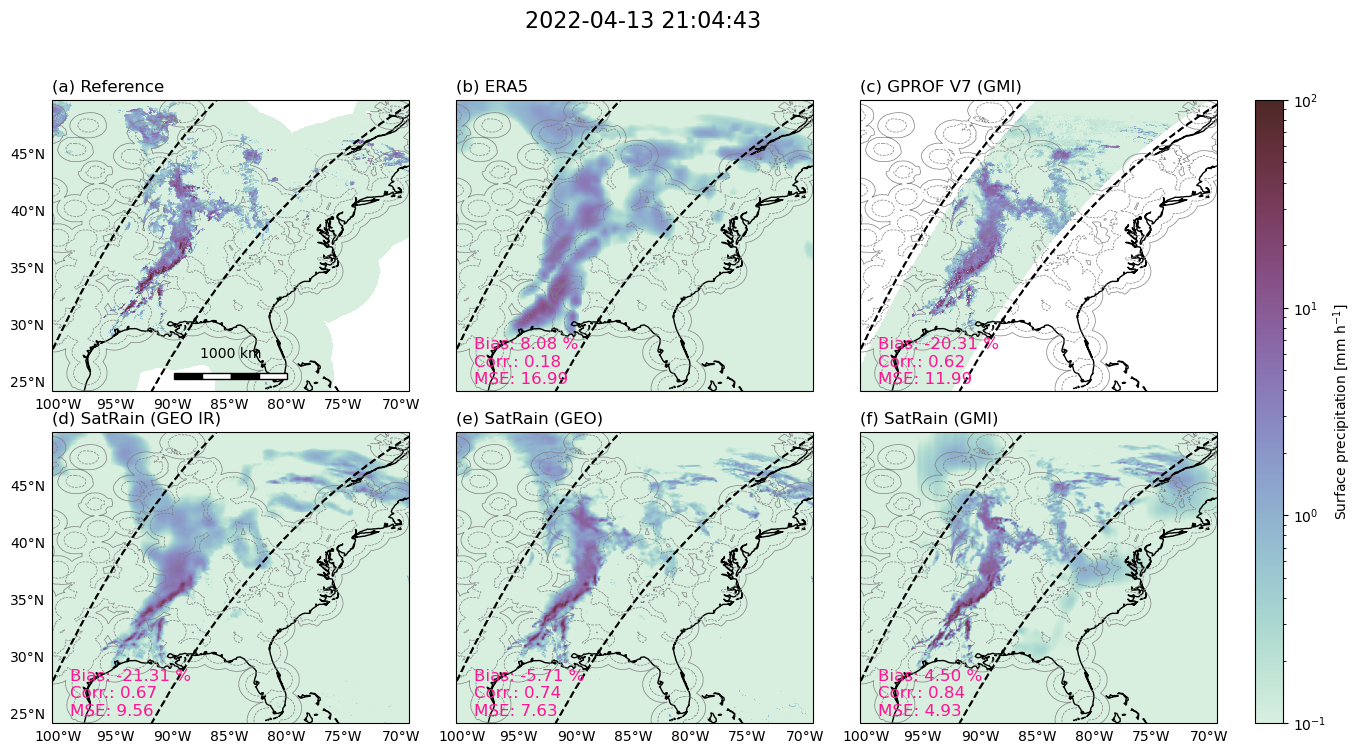

In [9]:
fig = evaluator.plot_retrieval_results(
    811,
    retrieval_fn={
        "ERA5": retrieve_era5,
        "GPROF V7 (GMI)": retrieve_gprof,
        "SatRain (GEO IR)": geo_ir_retrieval,
        "SatRain (GEO)": geo_retrieval,
        "SatRain (GMI)": gmi_retrieval
    },
    include_metrics=True,
    input_data_format="spatial",
    batch_size=32,
    tile_size=(256, 256),
    overlap=64,
    n_rows=2,
    contour_legend=False,
    swath_boundaries=True
)
fig.savefig("../case_study_convective.png", bbox_inches="tight", dpi=200)

In [14]:
from satrain.evaluation import Evaluator
from satrain.target import TargetConfig

domain = "austria"
evaluator = Evaluator(
    domain=domain,
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[
        {"name": "gmi", "normalize": "minmax", "nan": -2},
        #{#"name": "geo", "normalize": "minmax", "nan": -2, "channels": [1, 2, 4, 6, 7, 9, 10, 11, 14, 15]},
        {"name": "geo_ir", "normalize": "minmax", "nan": -2},
        {"name": "ancillary", "variables": ["total_precipitation"]},
    ],
    download=True,
)
print(f"Found {len(evaluator)} overpasses.")

Found 619 overpasses.


In [81]:
from pyresample.geometry import SwathDefinition
from pansat.utils import resample_data
from pansat.products.satellite.gpm import l2a_gprof_gpm_gmi_v07a, l2a_gprof_gpm_gmi_v07b

def retrieve_gprof(input_data: xr.Dataset) -> xr.Dataset:
    """
    Retrieval callback function to load GPROF data corresponding to IPWGML SPR evaluation data.

    Args:
        input_data: An xarray.Dataset containing the retrieval input data.

    Return:
        An xarray.Dataset containing the retrieval results.
    """
    time = input_data.time.mean().data
    recs = l2a_gprof_gpm_gmi_v07a.get(time)
    if len(recs) == 0:
        recs = l2a_gprof_gpm_gmi_v07b.get(time)
    rec = recs[0]
    input_file = input_data.attrs["gpm_input_file"]
    scan_start = input_data.attrs["scan_start"]
    scan_end = input_data.attrs["scan_end"]
    results_gprof = load_gprof_precip(rec.local_path, scan_start, scan_end)

    n_batches = input_data.batch.size
    batch_results = []
    for batch_ind in range(n_batches):
        tile = input_data[{"batch": batch_ind}]
        lons = tile.longitude.data
        lats = tile.latitude.data
        lons, lats = np.meshgrid(lons, lats)
        grid = SwathDefinition(lons, lats)
        print(grid.shape)
        results_gprof_r = resample_data(results_gprof, grid, radius_of_influence=10e3)
        batch_results.append(results_gprof_r.drop_vars(("latitude", "longitude")))
    return xr.concat(batch_results, dim="batch")

In [84]:
res = evaluator.evaluate_scene(3, tile_size=(256, 256), overlap=2, batch_size=128, input_data_format="spatial", retrieval_fn=retrieve_gprof)

DTYPE ::  float32
(256, 256)
[[51.60266774 51.60266774 51.60266774 ... 51.60266774 51.60266774
  51.60266774]
 [51.56628941 51.56628941 51.56628941 ... 51.56628941 51.56628941
  51.56628941]
 [51.52991108 51.52991108 51.52991108 ... 51.52991108 51.52991108
  51.52991108]
 ...
 [42.39894907 42.39894907 42.39894907 ... 42.39894907 42.39894907
  42.39894907]
 [42.36257074 42.36257074 42.36257074 ... 42.36257074 42.36257074
  42.36257074]
 [42.3261924  42.3261924  42.3261924  ... 42.3261924  42.3261924
  42.3261924 ]]


In [87]:
res.precip_flag.dtype

dtype('bool')

In [ ]:
plt.pcolormesh(res.precip_flag)
plt.colorbar()

In [79]:
res.precip_flag.dtype

dtype('bool')

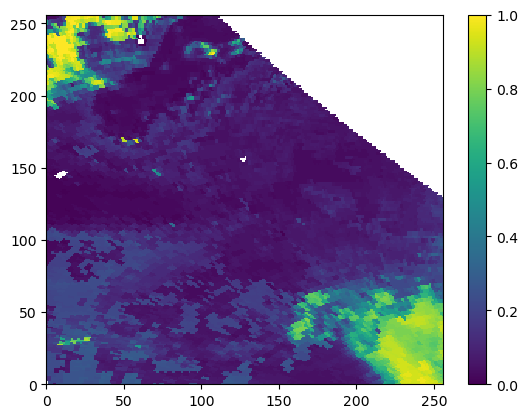

In [88]:
plt.pcolormesh(res.probability_of_precip)
plt.colorbar()

In [55]:
xr.load_dataset("gprof_v07a_gmi_austria.nc")

<xarray.Dataset> Size: 5kB
Dimensions:                 (scales: 24, threshold: 100, threshold_heavy: 100)
Coordinates:
  * scales                  (scales) float64 192B inf 0.846 ... 0.03845 0.03678
  * threshold               (threshold) float64 800B 0.0 0.0101 ... 0.9899 1.0
  * threshold_heavy         (threshold_heavy) float64 800B 0.0 0.0101 ... 1.0
Data variables: (12/19)
    bias                    float64 8B 67.05
    mae                     float64 8B 0.08881
    mse                     float64 8B 0.2809
    smape                   float64 8B 94.63
    correlation_coef        float64 8B 0.6344
    spectral_coherence      (scales) float64 192B nan nan nan ... nan nan nan
    ...                      ...
    pod_heavy               float64 8B 0.25
    far_heavy               float64 8B 0.9999
    hss_heavy               float64 8B -0.0003443
    precision_heavy         (threshold_heavy) float64 800B 1.383e-07 ... 0.0
    recall_heavy            (threshold_heavy) float64 800B 1.0 0.25 ... 0.0 0.0
    area_under_curve_heavy  float64 8B 0.0001024

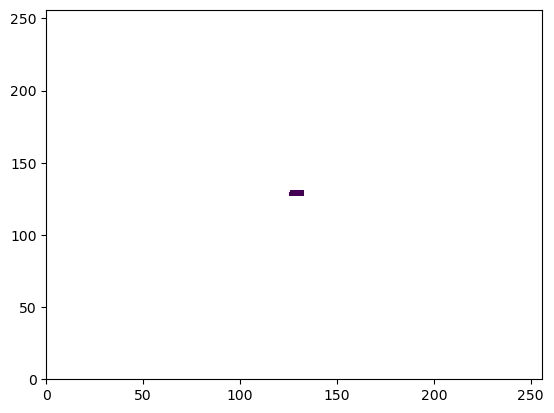

In [54]:
plt.pcolormesh(res.surface_precip_ref)

In [38]:
inpt.latitude

<xarray.DataArray 'latitude' (latitude: 256)> Size: 2kB
array([51.602668, 51.566289, 51.529911, ..., 42.398949, 42.362571, 42.326192])
Coordinates:
    latitude  (latitude) float64 2kB 51.6 51.57 51.53 51.49 ... 42.4 42.36 42.33

In [36]:
res = retrieve_gprof(inpt)

(1, 1)
[[51.60266774]]


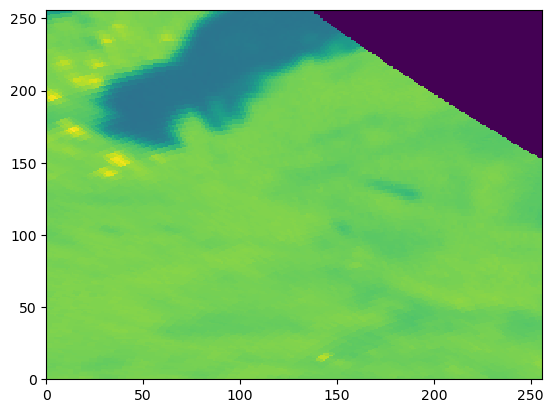

In [28]:
plt.pcolormesh(inpt.obs_gmi.data[0, 0])

In [33]:
res

<xarray.Dataset> Size: 19B
Dimensions:                      (batch: 1, latitude: 1, longitude: 1)
Dimensions without coordinates: batch, latitude, longitude
Data variables:
    surface_precip               (batch, latitude, longitude) float32 4B nan
    probability_of_precip        (batch, latitude, longitude) float64 8B -0.99
    precip_flag                  (batch, latitude, longitude) int16 2B -99
    probability_of_heavy_precip  (batch, latitude, longitude) float32 4B nan
    heavy_precip_flag            (batch, latitude, longitude) bool 1B False